# 300 名销售员，AI 助手该给谁？
### 同一个例子：Identification → Estimation → Policy

公司随机给销售员开放 AI 助手。同事可能共享信息，也可能争夺客户，因此影响可正可负。
**每个人只观察到一种情形，但分配名额需要比较“给他 / 不给他、同事获 AI 过半 / 未过半”四种情形。**
下面一直跟着“销售员甲”看：Identification 判断这些问题能否从总体数据中得到唯一答案，
Estimation 估出数值，Policy 据此分配名额。

## 1. 看数据：谁获得了 AI，合作同事中有多少人获得？

公司先记录合作关系和每个人的处理前特征，再独立地以 1/2 的概率向每人开放 AI，最后观察业绩。
以下用一位销售员贯穿全程，称他为“甲”。公式中的 A 始终表示合作网络的邻接矩阵。

本次展示使用已有预训练权重，并沿用权重对应的固定 ER300 网络：连边概率 0.02、905 条边。

<details><summary>重新运行需要什么？</summary>
将匹配的 model_best.pt 放到仓库的 checkpoints/er_estimation_demo/ 目录，或设置 CHECKPOINT。本 notebook 已保存实际运行结果，阅读图表不需要下载权重。没有权重时可切换 dense_smoke 检查流程，但它会使用另一张稠密图并现场训练极小模型，不是这里展示的预训练结果。
</details>

In [1]:
MODE = "checkpoint"  # pretrained presentation; "dense_smoke" only checks the pipeline
SEED = 2026
TASK_ID = 0
BUDGET = None  # None: checkpoint 用 60，dense_smoke 用 160；可指定 0..300
BUDGET_MODE = "at_most"
DEVICE = "cpu"
CHECKPOINT = None  # None: 仓库默认；也可填绝对路径或 checkpoints/ 下的模型名称

In [2]:
from pathlib import Path
from dataclasses import replace
from fractions import Fraction
from copy import deepcopy
import json
import base64
import os
import platform
import sys
import time
import uuid

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "pfn_pipeline" / "__init__.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("请从 ProjectCode/ 或其 notebooks/ 子目录启动内核。")
for path in (ROOT, ROOT / "notebooks"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown, HTML
from pfn_pipeline import (
    simulate_task, identify, replay_handoff, load_checkpoint, load_graph, train_model,
    estimate_effects, optimize_offline, effect_table, evaluate_estimates, evaluate_policy,
)
from pfn_pipeline._internal.paths import DEFAULT_GRAPH
from pfn_pipeline._internal.estimation.priors import DEFAULT_DGP
import er300_tutorial_helpers as viz
import shared_er_demo_helpers as show

if MODE not in {"checkpoint", "dense_smoke"}:
    raise ValueError("MODE 必须是 checkpoint 或 dense_smoke")
if BUDGET is None:
    BUDGET = 60 if MODE == "checkpoint" else 160
if not isinstance(BUDGET, int) or not 0 <= BUDGET <= 300:
    raise ValueError("BUDGET 必须是 0..300 的整数")
torch.set_num_threads(1)
FONT = viz.configure_style()
pd.set_option("display.max_columns", 10)
pd.set_option("display.max_colwidth", 85)
RUN_DIR = ROOT / "outputs" / "shared_er_demo" / f"{MODE}_{uuid.uuid4().hex[:10]}"
(RUN_DIR / "figures").mkdir(parents=True)
FIGURES = []

def show_figure(fig, name):
    fig.savefig(RUN_DIR / "figures" / f"{name}.png", dpi=145, bbox_inches="tight")
    FIGURES.append(name)
    display(fig)
    plt.close(fig)

model = None
if MODE == "checkpoint":
    model = load_checkpoint(CHECKPOINT or os.environ.get("CAUSALCFM_CHECKPOINT"), device=DEVICE)
    graph_record = model.graph_record
    DGP = model.provenance["dgp"]
    NOISE_SD = model.provenance["training_noise_sd"]
else:
    graph_record = json.loads(DEFAULT_GRAPH.read_text(encoding="utf-8"))
    assert (graph_record["n_units"], graph_record["edge_probability"], graph_record["seed"]) == (300, .5, 12345)
    DGP, NOISE_SD = DEFAULT_DGP, 4.0
adjacency = load_graph(graph_record)
STREAM = "scaling_v1/test" if DGP == DEFAULT_DGP else "test"
task, reference = simulate_task(seed=SEED, task_id=TASK_ID, stream=STREAM,
    adjacency=adjacency, dgp=DGP, noise_sd=NOISE_SD, budget=BUDGET,
    budget_mode=BUDGET_MODE, return_reference=True)
assert task.n_nodes == 300
assert task.metadata["graph_sha256"] == graph_record["adjacency_sha256"]
assert not ({"mu", "a", "a_seed"} & set(task.metadata))
assert task.x.shape == (task.n_nodes, 1)
neighbor_count, neighbor_fraction, majority_state = viz.exposure(adjacency, task.treatment)
nodes = pd.DataFrame({
    "node_id": task.node_ids,
    "销售员": [f"销售员 {i + 1}" for i in range(task.n_nodes)],
    "X_i": task.x[:, 0], "T_i": task.treatment, "Y_obs": task.outcome,
    "degree": adjacency.sum(1).astype(int), "K_i": neighbor_count,
    "E_i": neighbor_fraction, "S_i": majority_state,
})
FOCUS = int(np.argmin(np.abs(nodes.degree.to_numpy() - nodes.degree.median())))
DISPLAY_NAMES = {i: ("甲" if i == FOCUS else f"销售员 {i + 1}") for i in range(task.n_nodes)}

show.cards([
    ("共同网络", f"{task.n_nodes} 名销售员", f"{int(adjacency.sum()//2):,} 条边；连边 p={graph_record['edge_probability']}"),
    ("历史实验", "随机开放 AI", "每人的处理概率为 0.5"),
    ("本次名额", f"最多 {BUDGET} 人", "之后由 Policy 分配"),
])
if MODE == "dense_smoke":
    display(Markdown("**当前为稠密图小模型试跑：结果用于检查流程，不能评价正式模型质量。**"))
else:
    display(Markdown("**当前使用已有训练权重，并按权重记录匹配网络。**"))
show.details("运行环境与完整来源", json.dumps({"python": platform.python_version(),
    "torch": torch.__version__, "font": FONT, "graph": {k:v for k,v in graph_record.items() if k != "upper_hex"},
    "checkpoint": None if model is None else model.provenance}, indent=2, ensure_ascii=False))

**当前使用已有训练权重，并按权重记录匹配网络。**

### 先分清“人、合作关系、个人信息”

G=(V,A) 表示整张合作网络：V 是销售员名单，A 是记录两人是否合作的 0/1 表。
X_i 表示销售员 i 在开放 AI **之前**就已记录的个人特征；全体销售员的特征合在一起记作 **X**。

| 符号 | 直白地说是什么 |
| --- | --- |
| G=(V,A) | 公司里有哪些人、哪些人互相合作；A_ij=1 表示 i 与 j 有合作关系，0 表示没有。 |
| N(i) | 销售员 i 的合作同事名单：把 A 第 i 行中等于 1 的位置找出来。 |
| d_i | 这份名单里有多少人，即销售员 i 的合作同事数。 |
| X_i | 开放 AI 前记录的销售员 i 的个人特征；本例保持“处理前特征”这个含义。 |

$$\mathcal{N}(i)=\{j:A_{ij}=1\},\qquad d_i=|\mathcal{N}(i)|.$$

**本例固定的是合作关系 A 和全体处理前特征 X。** 谁拿到 AI 之后，才有处理变量 T 和实验结果 Y。
下面按同一批人分别列出“实验前已知的信息”和“实验发生后的记录”。

<details><summary>这份模拟数据的 X 是怎么来的？</summary>
当前代码用一列标准正态随机数 X_i ~ N(0,1) 表示处理前特征。
它是模拟数值；具体业务字段要由实际研究的数据定义。正态分布只是生成演示数据的设置，POINT 推导不要求 X 必须服从正态分布。
</details>

**实验前：** 合作同事数由网络算出，X 是处理前已记录的特征。

,处理前特征 X_i,合作同事数 d_i
销售员,,
甲,1.666,6
销售员 1,-0.739,8
销售员 3,-0.374,9
销售员 4,-0.004,9
销售员 5,-0.042,8


**实验后：** T=1 表示获得 AI；K 是获得 AI 的合作同事人数；S=1 表示该人数严格过半。

,是否获得 AI T_i,实验后业绩 Y_obs,获 AI 的同事数 K_i,是否严格过半 S_i
销售员,,,,
甲,0,-2.687,2,0
销售员 1,1,6.213,2,0
销售员 3,1,16.832,3,0
销售员 4,0,2.259,5,1
销售员 5,0,-5.797,4,0


**手算甲：** 他有 6 位合作同事，其中 2 位获得 AI。因为 2 ≤ 3，所以 S=0。正好一半归入 S=0。

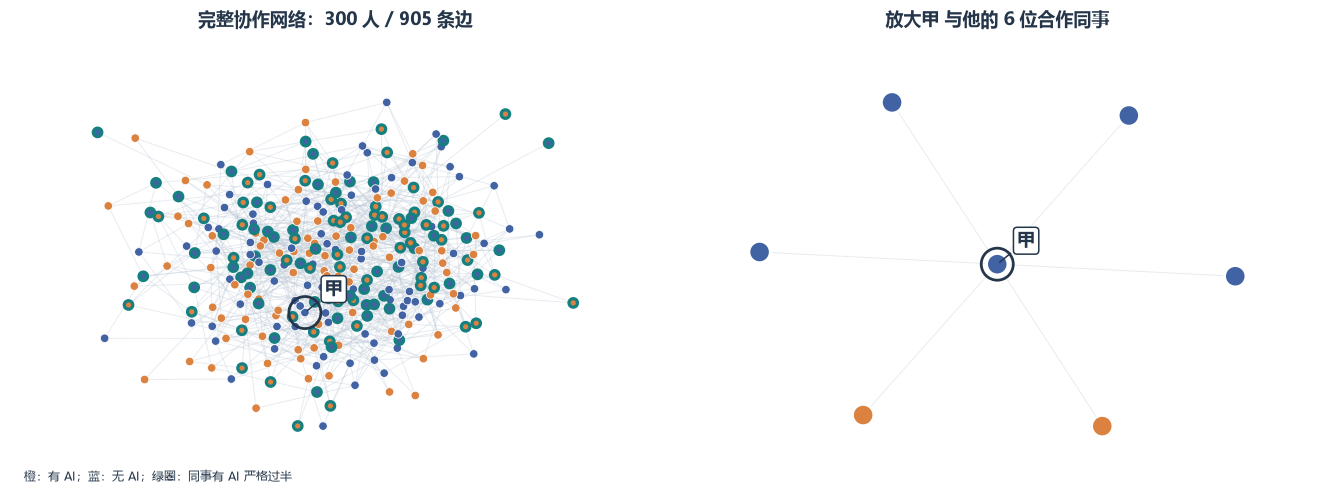

In [3]:
sample = nodes.iloc[[FOCUS, *[i for i in range(task.n_nodes) if i != FOCUS][:4]]].copy()
sample["销售员"] = [DISPLAY_NAMES[i] for i in sample.index]
display(Markdown("**实验前：** 合作同事数由网络算出，X 是处理前已记录的特征。"))
display(sample[["销售员", "X_i", "degree"]].rename(columns={
    "X_i": "处理前特征 X_i", "degree": "合作同事数 d_i"}).set_index("销售员").round(3))
display(Markdown("**实验后：** T=1 表示获得 AI；K 是获得 AI 的合作同事人数；S=1 表示该人数严格过半。"))
display(sample[["销售员", "T_i", "Y_obs", "K_i", "S_i"]].rename(columns={
    "T_i": "是否获得 AI T_i", "Y_obs": "实验后业绩 Y_obs",
    "K_i": "获 AI 的同事数 K_i", "S_i": "是否严格过半 S_i"}).set_index("销售员").round(3))
focus = nodes.iloc[FOCUS]
display(Markdown(f"**手算甲：** 他有 {int(focus.degree)} 位合作同事，"
    f"其中 {int(focus['K_i'])} 位获得 AI。因为 "
    f"{int(focus['K_i'])} {'>' if focus['S_i'] else '≤'} {int(focus.degree)//2}，"
    f"所以 S={int(focus['S_i'])}。正好一半归入 S=0。"))
show_figure(show.plot_network(task, FOCUS), "01_shared_graph")
show.details("甲对应的原始节点", task.node_ids[FOCUS])

## 2. 定目标：同一个人有四个问题

T_i=1 表示公司向 i 开放 AI，T_i=0 表示不开放。Y_i^{obs} 是实际分配发生后观察到的业绩。
对甲分别问：本人有 / 无 AI、合作同事有 AI 的人数过半 / 未过半时，平均业绩各是多少？

用 **t** 表示全体销售员的一种具体分配安排。先数合作同事中有多少人获得 AI，再判断是否严格过半：

$$K_i(\mathbf{t})=\sum_{j\in\mathcal{N}(i)}t_j,\qquad S_i(\mathbf{t})=\mathbf{1}\{K_i(\mathbf{t})>\lfloor d_i/2\rfloor\}.$$

这四种情形也叫“四臂”。Y_i((t,T_-i)) 表示本人分配为 t、其余人的分配为 T_-i 时的潜在业绩。
目标是在同一多数状态里，按实验设计对其余人的完整分配求平均：

$$\mu_i(t,s)=\mathbb{E}[Y_i((t,\mathbf{T}_{-i}))\mid S_i((t,\mathbf{T}_{-i}))=s,A,\mathbf{X}].$$

即固定个体 \(i\) 自己的处理状态为 \(t\)，让其他人的处理状态按照原实验设计随机变化，只保留那些使个体 \(i\) 的暴露状态为 \(s\) 的情况，再对个体 \(i\) 在这些情况下的潜在结果取平均。


**“过半 / 未过半”在这里是目标的分组规则。** 同样都是过半，具体由哪些同事获得 AI，仍然可以影响结果。

In [4]:
display(pd.DataFrame([["mu00", "mu01"], ["mu10", "mu11"]],
    index=["甲无 AI (T=0)", "甲有 AI (T=1)"],
    columns=["同事未过半 (S=0)", "同事严格过半 (S=1)"]))
display(Markdown(f"这次甲只落在 **{int(focus['T_i'])}{int(focus['S_i'])}** 这一格；"
                 "我们要估计的是四格各自的平均业绩，而不是把一次观测复制四遍。"))
spec = task.identification_spec
assert spec["exposure_mapping_claim"] == "UNSPECIFIED"

,同事未过半 (S=0),同事严格过半 (S=1)
甲无 AI (T=0),mu00,mu01
甲有 AI (T=1),mu10,mu11


这次甲只落在 **00** 这一格；我们要估计的是四格各自的平均业绩，而不是把一次观测复制四遍。

## 3. 查条件：满足什么条件，才能得到 POINT？

对上面的四臂目标，我们采用以下四项条件。

| 条件 | 直白地说，需要满足什么 | 在推导中有什么用 |
| --- | --- | --- |
| **1. 处理前信息固定** | 合作关系 A 和全体特征 X 在分配 AI 前已经确定；比较不同分配时，使用同一份 A、X。 | 明确我们比较的是同一批人、同一处理前背景下的不同分配。 |
| **2. 一致性** | 如果实际执行了某种完整分配 t，那么观察到的业绩就是这份分配对应的潜在业绩：Y_obs=Y(t)。 | 把实际观测结果与我们讨论的潜在结果连接起来。 |
| **3. 整组分配随机，规则已知** | 本例中每人独立地以 1/2 概率获得 AI；给定 A、X，整个分配向量与所有潜在结果独立。 | 分配不会按“谁在某种安排下会表现更好”来挑人，所以能去掉潜在结果均值中的分配条件。 |
| **4. 四种情形都有正概率** | 对每个人，本人有 / 无 AI × 同事过半 / 未过半这四格，在实验设计下都可能发生。 | 每一格的总体条件均值都有定义，能用它表达目标。 |

另需一个基本条件：**所讨论的平均业绩存在且有限**，这样期望值才有意义。
前三项需要由实验设计、处理前记录与处理定义来支持；第四项在下面按随机规则和合作同事数计算。
本例前三项来自合成实验设定；代码记录这些依据，并核验这条识别规则是否可用。

In [5]:
assumption_names = {
    "known_assignment_law": "条件 3：已知分配规则",
    "full_vector_randomization": "条件 3：整个分配向量随机",
    "consistency": "条件 2：实际结果对应实际完整分配",
    "fixed_pretreatment_network": "条件 1：固定处理前合作网络",
    "finite_conditional_first_moments": "基本条件：平均业绩存在且有限",
}
assumption_df = pd.DataFrame([{"对应条件": assumption_names[a["name"]],
    "状态": "已声明" if a["confirmed"] else "待补充", "依据": {
        "study_protocol": "实验协议", "demo_specification": "合成实验定义",
        "deterministic_derivation": "由生成机制推导"}.get(a["source"], a["source"])}
    for a in spec["assumptions"]])
assert all(a["confirmed"] for a in spec["assumptions"])
show.details("查看这些条件在代码中的声明与来源", json.dumps({
    "declarations": assumption_df.to_dict(orient="records"),
    "full_records": spec["assumptions"]}, indent=2, ensure_ascii=False))

**条件 4 怎么检查？把四格概率算出来。**

$$\pi_i(t,s)=\Pr(T_i=t,S_i=s\mid A,\mathbf{X}).$$

本例每人独立地以 1/2 概率获得 AI。因此有 d_i 位合作同事时，获 AI 的同事人数 K_i 服从二项分布：

$$K_i\mid A,\mathbf{X}\sim\mathrm{Binomial}(d_i,1/2),\qquad \pi_i(t,s)=\frac{1}{2}\sum_{k\in\mathcal{K}_i(s)}\binom{d_i}{k}2^{-d_i}.$$

这里的 K_i(s) 表示该多数状态允许的同事人数，求和范围很直接：未过半组取 0 到 floor(d_i/2)；过半组取 floor(d_i/2)+1 到 d_i。
本图每个人至少有一位合作同事，两组都非空，所以四格概率都大于 0。

左图是甲在实验设计下落入四格的概率；右图是这一次 300 人各落在哪一格。
某格这次观测少，会增加估计困难；只要设计概率仍大于 0，就不会因此把总体 POINT 改成 PARTIAL。

**把甲代进去：** d=6，因此有 AI 的同事至少达到 4 人才过半。按上面的二项式求和，P(S=1)=0.34375；所以 P(T=1,S=1)=0.5 × 0.34375 = 0.17188。

300 人 × 4 格 = 1200 个概率，全部大于 0；其中最小值为 0.1250。


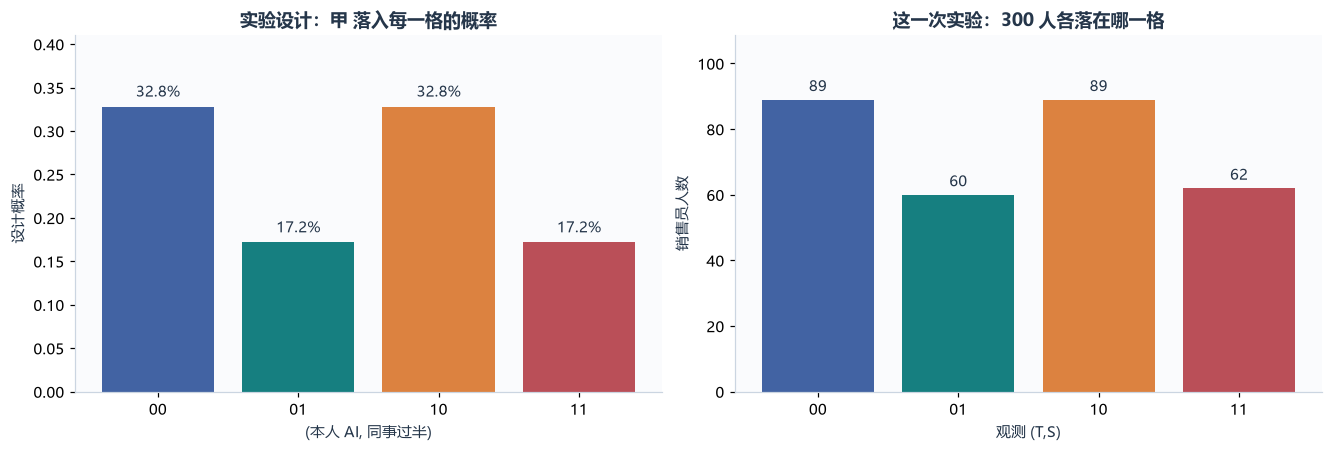

In [6]:
identified = identify(task)
assert (identified.status, identified.verification_status) == ("POINT", "VERIFIED")
response_id = identified.result["certificate"]["response_identification_result"]
tables = response_id["certificate"]["design_by_degree"]
support_rows = []
for i, degree in enumerate(adjacency.sum(1).astype(int)):
    table = tables[str(degree)]
    probabilities = table["joint_own_treatment_arm_probabilities"]
    assert sum(Fraction(x) for x in probabilities.values()) == 1
    for t in (0, 1):
        for s in (0, 1):
            exact = Fraction(probabilities[f"{t},{s}"])
            assert exact > 0
            support_rows.append({"node_id": task.node_ids[i], "degree": int(degree),
                                 "arm": f"{t}{s}", "probability": float(exact), "exact": str(exact)})
support_df = pd.DataFrame(support_rows)
focus_degree = int(focus.degree)
focus_probabilities = tables[str(focus_degree)]["joint_own_treatment_arm_probabilities"]
focus_high = Fraction(focus_probabilities["0,1"]) + Fraction(focus_probabilities["1,1"])
assert Fraction(focus_probabilities["1,1"]) == Fraction(1, 2) * focus_high
display(Markdown(f"**把甲代进去：** d={focus_degree}，因此有 AI 的同事至少达到 {focus_degree//2+1} 人才过半。"
    f"按上面的二项式求和，P(S=1)={float(focus_high):.5f}；"
    f"所以 P(T=1,S=1)=0.5 × {float(focus_high):.5f} = {float(Fraction(focus_probabilities['1,1'])):.5f}。"))
print(f"300 人 × 4 格 = {len(support_df)} 个概率，全部大于 0；其中最小值为 {support_df.probability.min():.4f}。")
show_figure(show.plot_support(support_df, task, FOCUS), "02_support_and_sample")

## 4. 得结论：为什么这四项条件足以得到 POINT？

**我们要证明：在上述条件下，目标均值可以写成总体观测分布的一个确定表达式。**
整段推导始终固定合作关系 A 与全体处理前特征 X。

### 4.1 先明确“对哪些安排求平均”

固定本人是否获得 AI，即 T_i=t，再看其余人的完整分配 **t**_-i。
只保留让同事多数状态等于 s 的那些分配；每种分配按实验设计赋权：

$$w(\mathbf{t}_{-i})=\Pr(\mathbf{T}_{-i}=\mathbf{t}_{-i}\mid A,\mathbf{X},T_i=t,S_i=s).$$

**在已经知道这个人属于 \(t,s\) 这一格以后，各种具体同事分配分别占多大比例。**

这些条件概率加起来等于 1。本人分配与其余人的分配独立，且同事状态不包含本人，
因此在本例中，加入 T_i=t 这个条件不会改变同一 s 组内的权重；它与目标定义中的设计平均一致。

### 4.2 三步推导，每一步用什么条件？

现在要证明：实验数据里四臂的总体平均值，就是刚才定义的这个设计平均潜在结果。

**第一步：用全期望公式展开。** 观测到同一格 (t,s) 时，背后可能对应不同的完整分配；分别求均值，再按其设计概率加权。**“这一格的平均业绩 = 每一种具体 assignment 下的平均业绩 × 它在这一格里的比例，然后全部加起来。”**

$$\mathbb{E}[Y_i^{\mathrm{obs}}\mid A,\mathbf{X},T_i=t,S_i=s]=\sum_{\mathbf{t}_{-i}:S_i((t,\mathbf{t}_{-i}))=s}\mathbb{E}[Y_i^{\mathrm{obs}}\mid A,\mathbf{X},\mathbf{T}=(t,\mathbf{t}_{-i})]w(\mathbf{t}_{-i}).$$

**第二步：使用一致性。** 实际执行的是 (t,t_-i)，观测结果就等于该安排对应的潜在结果（**把“实际观察到什么”连接到“这个干预安排下的潜在结果”**），上式等于

$$\sum_{\mathbf{t}_{-i}:S_i((t,\mathbf{t}_{-i}))=s}\mathbb{E}[Y_i((t,\mathbf{t}_{-i}))\mid A,\mathbf{X},\mathbf{T}=(t,\mathbf{t}_{-i})]w(\mathbf{t}_{-i}).$$

**第三步：使用整组随机化。** 给定处理前 A、X，整个分配向量与全部潜在结果独立（**哪个完整 assignment 被抽中，与“这个人在各个 assignment 下本来会表现多好”没有关系**）：

$$\mathbf{T}\perp\{Y_j(\mathbf{u}):j\in[N],\mathbf{u}\in\{0,1\}^{N}\}\mid A,\mathbf{X}.$$

所以去掉潜在结果均值中的分配条件，得到

$$\sum_{\mathbf{t}_{-i}:S_i((t,\mathbf{t}_{-i}))=s}\mathbb{E}[Y_i((t,\mathbf{t}_{-i}))\mid A,\mathbf{X}]w(\mathbf{t}_{-i})=\mu_i(t,s).$$

最后正好回到目标定义：对同一多数状态中的完整分配，按设计求平均。
求和保留了“具体哪些人获得 AI”的差别，因此无需额外假设“业绩只取决于本人处理和同事是否过半”。

### 4.3 得到总体观测表达式，因此是 POINT

上一节已算出四格概率 π_i(t,s)>0，因此这些总体条件均值有定义。把三步连起来：

$$\mu_i(t,s)=\mathbb{E}[Y_i^{\mathrm{obs}}\mid A,\mathbf{X},T_i=t,S_i=s].$$

右边完全由总体观测分布决定（如果我们真的有无限多次这个实验，我们就能唯一知道右边）。只要两个满足假设的因果世界有相同的观测分布，就必须给出相同的目标均值：

$$P_M(\mathbf{T},\mathbf{Y}^{\mathrm{obs}}\mid A,\mathbf{X})=P_{M'}(\mathbf{T},\mathbf{Y}^{\mathrm{obs}}\mid A,\mathbf{X})\Longrightarrow\mu_i^M(t,s)=\mu_i^{M'}(t,s).$$

**这就是 POINT：在已明确的目标与条件下，因果答案由总体观测分布唯一决定。**
它没有说一次有限实验已经准确知道了答案；数值如何估计、误差有多大，由下一步 Estimation 处理。

In [7]:
show.cards([("识别结论", identified.status.value, "总体观测分布决定唯一目标"),
            ("证明重验", identified.verification_status.value, "规则与声明核对通过")])
display(pd.DataFrame({"识别输出": ["目标", "使用的假设", "支持度", "交给 Estimation 的对象"],
    "内容": ["四臂设计平均响应", "上述四项条件，且平均业绩存在且有限", "每个人四格的设计概率均大于 0", f"{4*task.n_nodes} 个 mu_i(t,s)"]}))
show.details("完整 response 证明与 policy 组合记录", json.dumps({
    "response_status": response_id["status"], "response_functional": response_id["identified_functional"],
    "trace": response_id["trace"], "assumptions_used": response_id["assumptions_used"],
    "policy_functional": identified.result["identified_functional"]}, indent=2, ensure_ascii=False))

,识别输出,内容
0,目标,四臂设计平均响应
1,使用的假设,上述四项条件，且平均业绩存在且有限
2,支持度,每个人四格的设计概率均大于 0
3,交给 Estimation 的对象,"1200 个 mu_i(t,s)"


## 5. 做估计：把 1,200 个目标变成数值

PFN 是一个事先在许多模拟实验上训练好的预测模型。这里把当前实验的合作网络、处理前特征、分配和业绩
交给它，一次前向计算给出 300 人各自的四个均值；本次推断不再修改模型参数。
先检查识别交接，再看甲的四格数值与效应相减。POINT 说明目标唯一，有限数据的预测仍可能有误差。

<details><summary>这些定义怎样对应当前模型输入？</summary>
当前每人的五维观测输入为 [X_i, T_i, Y_i^{obs}, E_i, d_i/(N−1)]，邻接矩阵 A 另外输入。
其中 E_i=K_i/d_i 是获 AI 的合作同事比例；目标的分组仍按 S_i 是否严格过半。
X_i 与 d_i 是处理前信息，T_i、Y_i^{obs}、E_i 是本次实验的观测记录。
</details>

In [8]:
verified_request = replay_handoff(identified)
request = verified_request.model_dump(mode="json")
response_request = request.get("response_request", request)
program = response_request["program"]
show.details("完整交接字段", json.dumps({"request_type": request["request_type"],
    "target_count": 4*task.n_nodes, "arm_order": ["00", "01", "10", "11"], "output_shape": [300, 2, 2],
    "response_request_type": response_request["request_type"],
    "assignment_probability": program["assignment_probability_rational"],
    "network_fingerprint": program["network_fingerprint"]}, indent=2, ensure_ascii=False))

In [9]:
if model is None:
    checkpoint = train_model(RUN_DIR / "smoke_training", graph_file=str(DEFAULT_GRAPH),
        dgp=DGP, noise_sd=NOISE_SD, cache_dir=str(RUN_DIR / "smoke_cache"), device=DEVICE,
        train_tasks=2, validation_tasks=1, epochs=1, batch_size=1,
        num_layers=1, d_model=16, num_heads=2, threads=1)
    model = load_checkpoint(checkpoint, device=DEVICE)
assert np.array_equal(load_graph(model.graph_record), adjacency)
assert model.provenance["dgp"] == task.metadata["dgp"]
parameters_before = viz.parameter_digest(model)
started = time.perf_counter()
estimates = estimate_effects(task, identified, model)
inference_seconds = time.perf_counter() - started
assert estimates.center.shape == (300, 2, 2)
assert estimates.identification is identified and estimates.task is task
assert viz.parameter_digest(model) == parameters_before
assert estimates.provenance["graph_matches_training"]
assert np.isfinite(estimates.center).all()
print("模型与本次数据的网络、生成机制匹配；300 人的四格预测已完成。")
estimated_effects = effect_table(estimates.center)
estimate_df = pd.DataFrame(estimates.center.reshape(task.n_nodes, 4),
                           columns=["mu00", "mu01", "mu10", "mu11"])
estimate_df.insert(0, "node_id", task.node_ids)
for j, name in enumerate(("direct", "spillover", "total")):
    estimate_df[name] = estimated_effects[:, j]
focus_mu = estimates.center[FOCUS]
display(Markdown("**甲的四格平均业绩预测：** 表格位置与第 2 步完全一致。"))
display(pd.DataFrame(focus_mu, index=["甲无 AI (T=0)", "甲有 AI (T=1)"],
    columns=["同事未过半 (S=0)", "同事严格过半 (S=1)"]).round(3))
display(pd.DataFrame({"甲的效应": ["本人获得 AI", "同事获 AI 过半", "两者合在一起"],
    "比较条件": ["同事都在未过半组", "本人保持有 AI", "从 00 到 11"],
    "怎样算": [f"mu10 - mu00 = {focus_mu[1,0]:.3f} - ({focus_mu[0,0]:.3f})",
                f"mu11 - mu10 = {focus_mu[1,1]:.3f} - ({focus_mu[1,0]:.3f})",
                f"mu11 - mu00 = {focus_mu[1,1]:.3f} - ({focus_mu[0,0]:.3f})"],
    "结果": estimated_effects[FOCUS]}).round(3))

模型与本次数据的网络、生成机制匹配；300 人的四格预测已完成。


**甲的四格平均业绩预测：** 表格位置与第 2 步完全一致。

,同事未过半 (S=0),同事严格过半 (S=1)
甲无 AI (T=0),-1.330,-1.623
甲有 AI (T=1),6.302,6.001


,甲的效应,比较条件,怎样算,结果
0,本人获得 AI,同事都在未过半组,mu10 - mu00 = 6.302 - (-1.330),7.632
1,同事获 AI 过半,本人保持有 AI,mu11 - mu10 = 6.001 - (6.302),-0.301
2,两者合在一起,从 00 到 11,mu11 - mu00 = 6.001 - (-1.330),7.331


**再看估得准不准。** 合成实验允许我们在事后揭示真值，比较甲的四个预测；
真值没有交给估计或选人算法。本次误差用于检查这一个案例。

全体 1,200 个预测的均方根误差（RMSE）= 0.888 分。


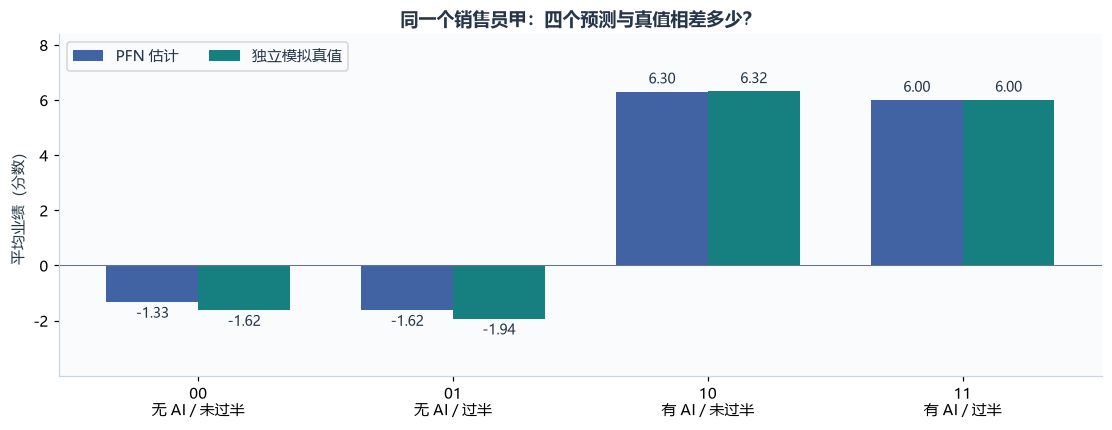


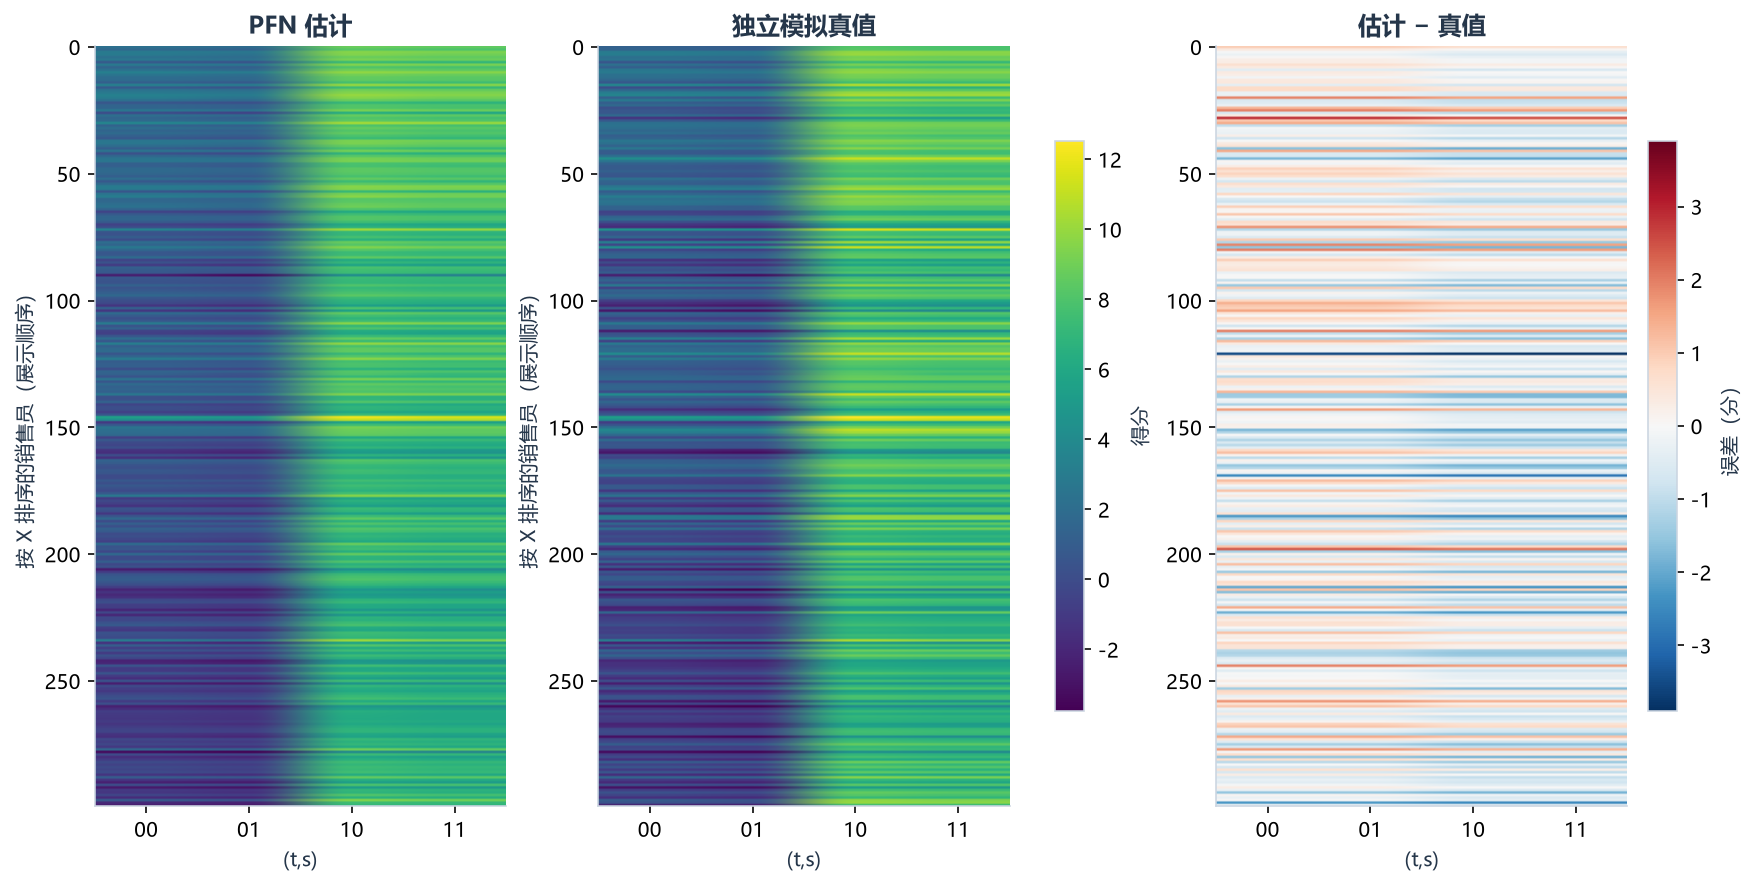

In [10]:
truth_mu = reference["mu"]
true_effects = effect_table(truth_mu)
estimate_metrics = evaluate_estimates(estimates, reference)
print(f"全体 1,200 个预测的均方根误差（RMSE）= {estimate_metrics['response_surface']['rmse']:.3f} 分。")
show_figure(show.plot_focus_estimates(estimates.center, truth_mu, FOCUS), "03_four_arm_estimates")
heatmap = viz.plot_surfaces(task, estimates.center, truth_mu)
for ax in heatmap.axes:
    if "员工" in ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel().replace("员工", "销售员"))
heatmap_path = RUN_DIR / "figures" / "03b_all_nodes_heatmap.png"
heatmap.savefig(heatmap_path, dpi=145, bbox_inches="tight")
plt.close(heatmap)
FIGURES.append("03b_all_nodes_heatmap")
encoded = base64.b64encode(heatmap_path.read_bytes()).decode("ascii")
display(HTML('<details><summary>补充：全部 300 人的四臂预测与误差热图</summary>'
             f'<img alt="全体节点四臂估计、真值与误差" src="data:image/png;base64,{encoded}" /></details>'))

## 6. 做决策：有限 AI 名额怎么分？

每加入一个人，都重新计算同事的多数状态，再算四臂响应评分：
用候选方案确定每人落在哪一格，再取那一格的预测，求全体平均。

**在“最多给 \(B\) 个人 AI”的约束下，找一组人，使全体 300 人按照最终状态取到的预测业绩平均值尽量大。**

$$\widehat{Q}(z)=\frac{1}{N}\sum_i\widehat{\mu}_i(z_i,S_i(z)),\quad \sum_i z_i\leq B.$$

\(z_i=1\) 表示最终给第 \(i\) 个销售员 AI，\(z_i=0\) 表示不给。给定一个完整方案 \(z\) 以后，根据网络重新计算每个人的同事是否‘严格过半’获得 AI，也就是 \(S_i(z)\)。然后每个人从前面 Estimation 得到的四格预测里取对应的一格，最后 300 人取平均，就是这个分配方案的预测评分。

下面展示前几步的“本人贡献 + 同事贡献 = 净增益”，以及最终选择。
优化目标是这个多数响应评分；贪心结果没有全局最优保证，也不自动等于真实 rollout 业绩。

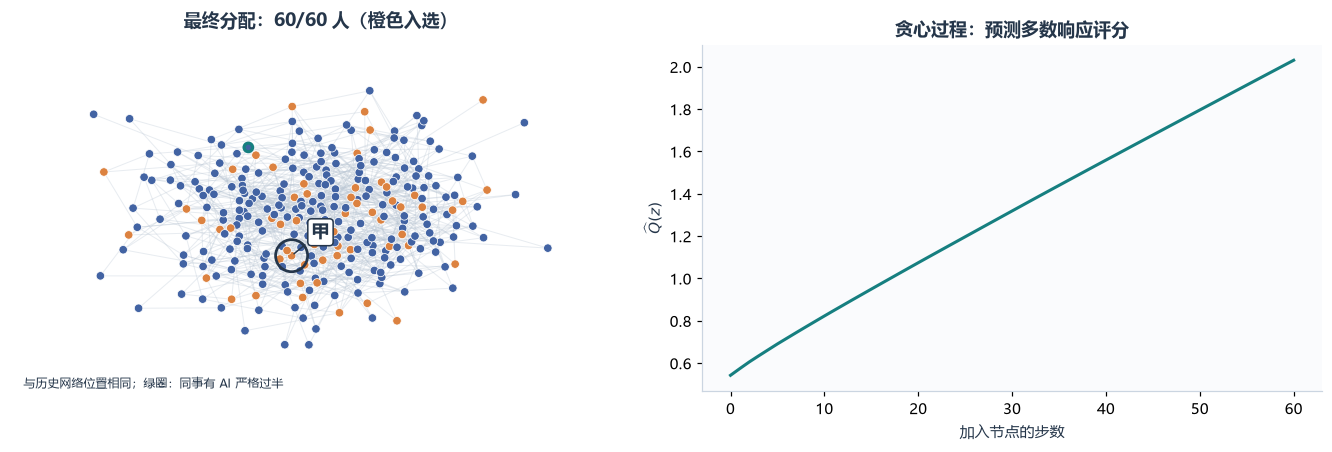

最终甲 **获得 AI**，合作同事获得 AI 未过半；因此评分取甲的 **10** 格。

,步骤,加入的人,本人贡献,同事贡献,净增益
0,1,销售员 87,0.03197,0.0,0.03197
1,2,销售员 167,0.03117,0.0,0.03117
2,3,销售员 113,0.02876,0.0,0.02876
3,4,销售员 267,0.02819,0.0,0.02819
4,5,销售员 154,0.02808,0.0,0.02808
5,6,销售员 272,0.02673,0.0,0.02673


**拆开其中一步：** 第 60 步加入 销售员 34，使 1 位同事跨过多数阈值。本人贡献 0.02512 + 同事贡献 -0.00171 = 净增益 0.02341（网络平均评分）。

In [11]:
policy = optimize_offline(task, estimates)
assert not policy.abstain and policy.feasible
assert policy.estimates is estimates and policy.task is task
assert policy.budget_used <= BUDGET
np.testing.assert_allclose(policy.predicted_value, viz.score(adjacency, estimates.center, policy.allocation))
np.testing.assert_array_equal(policy.resulting_exposure, viz.exposure(adjacency, policy.allocation)[2])
policy_metrics = evaluate_policy(policy, reference)
stop_labels = {"budget_reached": "已达到预算上限", "no_positive_single_node_gain": "再增加一人已没有正的预测增益"}
show.cards([("实际开放 AI", f"{policy.budget_used} / {BUDGET}", stop_labels.get(policy.stop_reason, policy.stop_reason)),
            ("多数暴露人数", int(policy.resulting_exposure.sum()), "按最终分配重算 S(z)"),
            ("预测评分增量", f"{policy.objective_gain:+.4f}", "相对全零计划的 Q 增量")])
show_figure(show.plot_policy(task, policy, FOCUS), "04_allocation_and_trace")
display(Markdown(f"最终甲 **{'获得' if policy.allocation[FOCUS] else '未获得'} AI**，"
    f"合作同事获得 AI {'严格过半' if policy.resulting_exposure[FOCUS] else '未过半'}；"
    f"因此评分取甲的 **{int(policy.allocation[FOCUS])}{int(policy.resulting_exposure[FOCUS])}** 格。"))
trace_df = pd.DataFrame(policy.trace)
if not trace_df.empty:
    trace_display = trace_df[["step", "selected_node", "own_gain", "neighbor_gain", "marginal_gain"]].copy()
    trace_display["selected_node"] = trace_display["selected_node"].map(DISPLAY_NAMES)
    display(trace_display.rename(columns={"step": "步骤", "selected_node": "加入的人", "own_gain": "本人贡献",
                         "neighbor_gain": "同事贡献", "marginal_gain": "净增益"}).head(6).round(5))
    one_step = max(policy.trace, key=lambda row: len(row["newly_high_exposure_nodes"]))
    display(Markdown(f"**拆开其中一步：** 第 {one_step['step']} 步加入 "
        f"{DISPLAY_NAMES[one_step['selected_node']]}，使 {len(one_step['newly_high_exposure_nodes'])} 位同事跨过多数阈值。"
        f"本人贡献 {one_step['own_gain']:.5f} + 同事贡献 {one_step['neighbor_gain']:.5f} "
        f"= 净增益 {one_step['marginal_gain']:.5f}（网络平均评分）。"))
min_threshold = int((adjacency.sum(1).astype(int)//2 + 1).min())
show.details("预算为什么会影响同事效应的展示", f"本图最小严格多数阈值为 {min_threshold}。"
    "如果预算低于它，任何计划都无法让节点达到 S=1。稠密模式的预算设为 160，以允许出现阈值切换。")

**同预算比较。** 先按图或估计选人，之后才用模拟真值评分。
随机方案重复 40 次；误差线是方案之间的标准差。

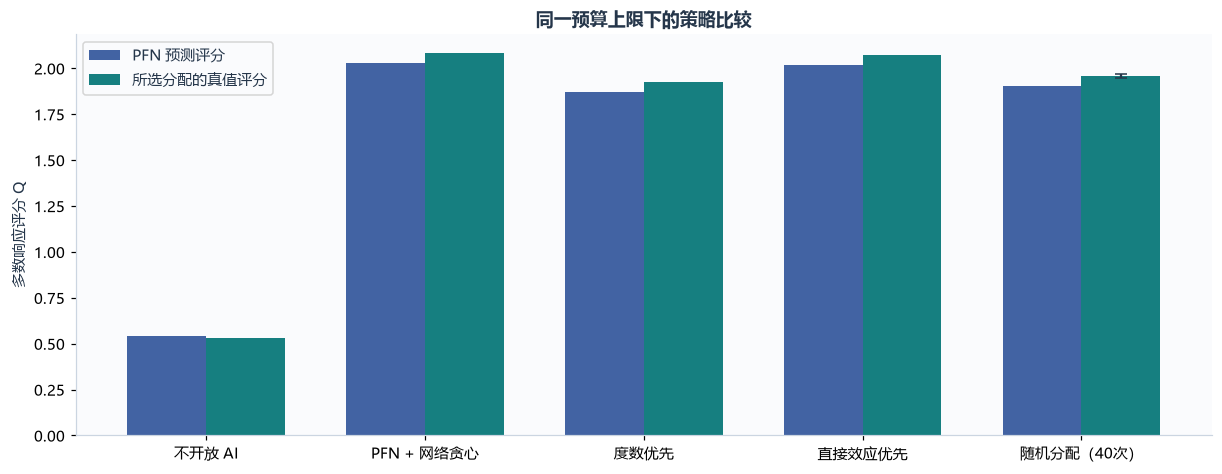

In [12]:
candidates, random_allocations = viz.comparison_frame(task, estimates, policy, draws=40, seed=8102)
comparison_rows = [{"策略": name.replace("不安排培训", "不开放 AI"), "人数": int(z.sum()),
    "预测评分": viz.score(adjacency, estimates.center, z), "真值评分": viz.score(adjacency, truth_mu, z),
    "随机真值标准差": 0.0} for name, z in candidates.items()]
random_truth = np.array([viz.score(adjacency, truth_mu, z) for z in random_allocations])
comparison_rows.append({"策略": "随机分配（40次）", "人数": BUDGET,
    "预测评分": float(np.mean([viz.score(adjacency, estimates.center, z) for z in random_allocations])),
    "真值评分": float(random_truth.mean()), "随机真值标准差": float(random_truth.std(ddof=1))})
comparison = pd.DataFrame(comparison_rows)
show_figure(viz.plot_comparison(comparison), "05_policy_comparison")

## 7. 看停止案例，再总结交付物

最后保留同样的网络与观测数据，只把随机化假设改成“未确认”或“拒绝采用”。
真实运行结果如下：前者需要补充依据，后者不支持当前路线，两者都停止估计和策略。
这说明识别模块在决定后续计算能否进行。

In [13]:
gate_rows = [{"随机化状态": "CERTIFIED", "工作流": identified.diagnostics["workflow_status"],
              "识别状态": identified.status.value, "有估计请求": identified.estimation_request is not None}]
blocked_cases = []
for status, source, expected in [("UNRESOLVED", "unresolved_input", "NEEDS_INPUT"),
                                  ("NOT_ADMITTED", "human_confirmation", "UNSUPPORTED")]:
    changed = deepcopy(spec)
    for item in changed["assumptions"]:
        if item["name"] == "full_vector_randomization":
            item.update(status=status, source=source, confirmed=False)
    blocked_task = replace(task, identification_spec=changed, assumptions=tuple(changed["assumptions"]))
    blocked_id = identify(blocked_task)
    assert blocked_id.diagnostics["workflow_status"] == expected
    assert blocked_id.estimation_request is None
    blocked_cases.append((blocked_task, blocked_id))
    gate_rows.append({"随机化状态": status, "工作流": blocked_id.diagnostics["workflow_status"],
                     "识别状态": blocked_id.status.value, "有估计请求": False})
gate_df = pd.DataFrame(gate_rows)
stop_rows = []
for blocked_task, blocked_id in blocked_cases:
    unavailable = estimate_effects(blocked_task, blocked_id, model)
    abstained = optimize_offline(blocked_task, unavailable)
    assert unavailable.center is None and abstained.abstain and abstained.allocation is None
    stop_rows.append({"工作流": blocked_id.diagnostics["workflow_status"],
                      "估计结果": unavailable.kind, "策略停止": abstained.abstain})
display(pd.DataFrame({
    "随机化依据": gate_df["随机化状态"].map({"CERTIFIED": "已确认", "UNRESOLVED": "待补充", "NOT_ADMITTED": "明确拒绝采用"}),
    "识别模块给出的结论": gate_df["工作流"].map({"COMPLETE": "目标有唯一答案（POINT）", "NEEDS_INPUT": "需要补充依据", "UNSUPPORTED": "当前路线不支持"}),
    "后续估计与分配": gate_df["有估计请求"].map({True: "继续", False: "停止"}),
}))
show.details("对应的实际返回状态", json.dumps({"identification": gate_rows,
    "downstream": stop_rows}, indent=2, ensure_ascii=False))

,随机化依据,识别模块给出的结论,后续估计与分配
0,已确认,目标有唯一答案（POINT）,继续
1,待补充,需要补充依据,停止
2,明确拒绝采用,当前路线不支持,停止


**三步各解决一个问题：** 在什么条件下能回答？四格平均业绩是多少？有限名额按评分怎么分？
完整假设、证明、估计和分配均保存在本次输出目录，可供复查。

In [14]:
assert viz.parameter_digest(model) == parameters_before
assert tuple(estimates.diagnostics["marginal_gmms"]["arm_order"]) == ("mu00", "mu01", "mu10", "mu11")
np.testing.assert_allclose(estimated_effects[:, 2], estimated_effects[:, 0] + estimated_effects[:, 1])
assert tuple(reference["node_ids"]) == task.node_ids
assert task.metadata["graph_sha256"] == model.provenance["training_graph_sha256"]
assert not ({"mu", "a", "a_seed"} & set(task.metadata))
assert policy_metrics["actual_rollout_welfare"] == "not_evaluated"

def save_json(name, value):
    path = RUN_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

save_json("observed/graph.json", graph_record)
save_json("observed/nodes.json", nodes.to_dict(orient="records"))
save_json("observed/feature_dictionary.json", {
    "raw_feature_dimension": 1,
    "X_i": {"source": "iid Normal(0,1)", "meaning": "处理前已记录的个人特征（模拟数值）", "pretreatment": True},
    "G": {"meaning": "G=(V,A): population and cooperation network", "source": "fixed adjacency A", "pretreatment": True},
    "d_i": {"source": "sum_j A_ij", "pretreatment": True},
    "T_K_E_S_Y": {"source": "assignment and experiment", "pretreatment": False},
    "factual_token_order": ["X_i", "T_i", "Y_i", "E_i", "d_i/(N-1)"],
})
save_json("identification/result.json", identified.result)
save_json("identification/request.json", request)
save_json("identification/assumptions.json", spec["assumptions"])
save_json("identification/stop_cases.json", gate_rows)
save_json("estimation/node_predictions.json", estimate_df.to_dict(orient="records"))
save_json("policy/allocation.json", [{"node_id": node, "selected": int(policy.allocation[i]),
    "resulting_exposure": int(policy.resulting_exposure[i])} for i, node in enumerate(task.node_ids)])
save_json("policy/trace.json", list(policy.trace))
save_json("evaluation_reference/mechanism.json", reference["metadata"])
np.save(RUN_DIR / "evaluation_reference" / "mu.npy", truth_mu)
save_json("evaluation_reference/comparison.json", comparison.to_dict(orient="records"))
report = {"mode": MODE, "purpose": "smoke_only" if MODE == "dense_smoke" else "matched_checkpoint_demo",
    "seed": SEED, "task_id": TASK_ID, "stream": STREAM, "dgp": DGP,
    "focus_node_id": task.node_ids[FOCUS],
    "graph": {k:v for k,v in graph_record.items() if k != "upper_hex"},
    "checkpoint": model.provenance, "budget": BUDGET, "budget_mode": BUDGET_MODE,
    "identification": {"status": identified.status.value, "verification": identified.verification_status.value,
                       "workflow": identified.diagnostics["workflow_status"], "arm_mean_count": len(support_df)},
    "response_shape": list(estimates.center.shape), "estimate_metrics": estimate_metrics,
    "policy_metrics": policy_metrics, "stop_cases": stop_rows, "checks_passed": True,
    "figures": FIGURES, "run_directory": str(RUN_DIR)}
save_json("summary.json", report)
show.cards([("Identification", "POINT / VERIFIED", f"{len(support_df)} 个响应目标；假设缺失会停下"),
            ("Estimation", "四臂预测已完成", f"响应 RMSE={estimate_metrics['response_surface']['rmse']:.3f}"),
            ("Policy", "预算可行", f"{policy.budget_used} 人入选；未宣称全局最优")])

数值来自与本例网络和数据生成设置匹配的预训练模型，展示本次合成实验的估计与决策结果。